# Latent state estimation (filtering and smoothing) for a partially observed, irregularly-sampled, continuous-discrete (non-linear) Gaussian dynamical system

We show how to use cd-dynamax to estimate the latent state of a continuous-discrete (non-linear) Gaussian dynamical system

Specifically, we will showcase the following alternatives:

- The Extended Kalman Filter (EKF)
- The Extended Kalman Smoother (EKS)

## Preliminaries

### Code Setup

In [1]:
# Main imports
import sys
from itertools import count

# Import jax and utils
from jax import numpy as jnp
import jax.random as jr
from typing import Union
from jaxtyping import Float, Array

# Import dynamax
sys.path.append("../../..")
from dynamax.parameters import ParameterProperties

# Our own custom src codebase
sys.path.append("../..")
# continuous-discrete nonlinear Gaussian SSM codebase
# CD-Nonlinear Gaussian models
from continuous_discrete_nonlinear_gaussian_ssm.models import *
from continuous_discrete_nonlinear_gaussian_ssm import ContDiscreteNonlinearGaussianSSM
# CD-Nonlinear Gaussian filters and smoother
from continuous_discrete_nonlinear_gaussian_ssm import cdnlgssm_filter, cdnlgssm_forecast
from continuous_discrete_nonlinear_gaussian_ssm import cdnlgssm_smoother
# Useful utility functions
from simulation_utils import *

# Plotting
import matplotlib
%matplotlib inline
# Our own custom plotting codebase
from utils.plotting_utils import *
from lorenz_plotting import *
# Feel free to change the default figure size
#matplotlib.rcParams['figure.figsize'] = [16, 9]

# For pretty print of ndarrays
jnp.set_printoptions(formatter={"float_kind": "{:.2f}".format})

## True model set up

We generate data from a Lorenz 63 system, from dynamics with the following stochastic differential equations:

\begin{align*}
\frac{d x}{d t} &= a(y-x) + \sigma w_x(t) \\
\frac{d y}{d t} &= x(b-z) - y + \sigma w_y(t) \\
\frac{d z}{d t} &= xy - cz + \sigma w_z(t),
\end{align*}

With parameters $a=10, b=28, c=8/3$, the system gives rise to chaotic behavior, and we choose $\sigma=1.0$ for diffusion.

To generate data, we numerically approximate random path solutions to this SDE using Heun's method (i.e. improved Euler), as implemented in [Diffrax](https://docs.kidger.site/diffrax/api/solvers/sde_solvers/).


We assume the observation model is
\begin{align*}
y(t) &= H x(t) + r(t) \\
r(t) &\sim N(0,R),
\end{align*}
where we choose $R=I$. 

Namely, **we impose partial observability with H=[1, 0, 0]**, with noisy observations, sampled at irregular time intervals.

### True, data-generating model definition

In [2]:
## Main settings
state_dim = 3
emission_dim = 1

# Define a custom drift model, inherited from LearnableFunction
class lorenz63_drift(LearnableFunction):
    params: Union[Float[Array, "state_dim"], ParameterProperties]

    def f(self, x, u=None, t=None):
        foo = jnp.array(
            [
                self.params[0] * (x[1] - x[0]),
                self.params[1] * x[0] - x[1] - x[0] * x[2],
                -self.params[2] * x[2] + x[0] * x[1],
            ]
        )
        return foo

# Define the true parameters of the drift function
true_l63_drift_params = jnp.array([10.0, 28.0, 8 / 3])
# And the corresponding Lorenz 63 system
true_drift = {
    "params": lorenz63_drift(
        params=true_l63_drift_params
    ),
    "props": lorenz63_drift(
        params=ParameterProperties()
    ),
}

# Define the true parameters of the diffusion function
true_diffusion_cov = {
    "params": LearnableMatrix(
        params=jnp.eye(state_dim)
    ),
    "props": LearnableMatrix(
        params=ParameterProperties(
            constrainer=RealToPSDBijector()
        )
    ),
}

# Define the true parameters of the diffusion function
true_diffusion_coefficient_param = 1.0
true_diffusion_coefficient = {
    "params": LearnableMatrix(
        params=true_diffusion_coefficient_param * jnp.eye(state_dim)
    ),
    "props": LearnableMatrix(
        params=ParameterProperties()
    ),
}

# Define the true parameters of the emission function
# Partial observability
H=jnp.array(
    [[1.0, 0.0, 0.0]]
)
true_emission = {
    "params": LearnableLinear(
        weights=H,
        bias=jnp.zeros(emission_dim)
    ),
    "props": LearnableLinear(
        weights=ParameterProperties(),
        bias=ParameterProperties()
    ),
}

# Define the true parameters of the emission covariance
R=jnp.eye(emission_dim)
true_emission_cov = {
    "params": LearnableMatrix(
        params=R
    ),
    "props": LearnableMatrix(
        params=ParameterProperties(
            constrainer=RealToPSDBijector()
        )
    ),
}

# Define the true initial mean and covariance
true_initial_mean = {
    "params": LearnableVector(
        params=jnp.zeros(state_dim)
    ),
    "props": LearnableVector(
        params=ParameterProperties()
    ),
}

true_initial_cov_param = 5.0
true_initial_cov = {
    "params": LearnableMatrix(
        params=true_initial_cov_param*jnp.eye(state_dim)
    ),
    "props": LearnableMatrix(
        params=ParameterProperties(
            constrainer=RealToPSDBijector()
        )
    ),
}

# Concatenate all parameters in dictionary, for later easy use
all_true_params = {
    'initial_mean': true_initial_mean,
    'initial_cov': true_initial_cov,
    'dynamics_drift': true_drift,
    'dynamics_diffusion_coefficient': true_diffusion_coefficient,
    'dynamics_diffusion_cov': true_diffusion_cov,
    'dynamics_approx_order': 2., # Check on this later
    'emission_function': true_emission,
    'emission_cov': true_emission_cov,
}

# Simulation 1: Fast sample rate and modest initial state covariance

### Simulation set-up

In [3]:
# Set up seed for simulation
keys = map(jr.PRNGKey, count())

# Simulation parameters
T_filter = 40
T_total = 50
num_timesteps_total = 10000

# Generate time points for measurements, filtering and forecasting
sim1_t, sim1_t_filter, sim1_t_forecast, \
    sim1_num_timesteps, sim1_num_timesteps_filter, sim1_num_timesteps_forecast= \
    generate_irregular_t_emissions(
        T_total=T_total,
        num_timesteps=num_timesteps_total,
        T_filter=T_filter,
        key=next(keys)
    )


### Model creation: object instantiation, with modest initial state covariance

In [4]:
# Model parameters for simulation
# Initial covariance is "moderate"
sim1_state_sd = 5.0
sim1_initial_cov_param = {
    "params": LearnableMatrix(
        params=sim1_state_sd**2 *jnp.eye(state_dim)
    ),
    "props": LearnableMatrix(
        params=ParameterProperties(
            constrainer=RealToPSDBijector()
        )
    ),
}

# Concatenate all parameters in dictionary, for later easy use
all_sim1_params = {
    'initial_mean': true_initial_mean,
    'initial_cov': sim1_initial_cov_param,
    'dynamics_drift': true_drift,
    'dynamics_diffusion_coefficient': true_diffusion_coefficient,
    'dynamics_diffusion_cov': true_diffusion_cov,
    'dynamics_approx_order': 2., # Check on this later
    'emission_function': true_emission,
    'emission_cov': true_emission_cov,
}

# Create CD-NLGSSM model
sim1_model = ContDiscreteNonlinearGaussianSSM(state_dim, emission_dim)
sim1_params, _ = sim1_model.initialize(
    next(keys),
    **all_sim1_params
)

### Simulate data: sample from model

In [5]:
# sample true states and emissions from defined true model.
# Using transition_type="path" to solve the dynamics SDE.
sim1_states, sim1_emissions = sim1_model.sample(
    sim1_params,
    next(keys),
    sim1_num_timesteps,
    sim1_t,
    transition_type="path" # uses the Euler-Maruyama method
)

Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


### Plot generated data

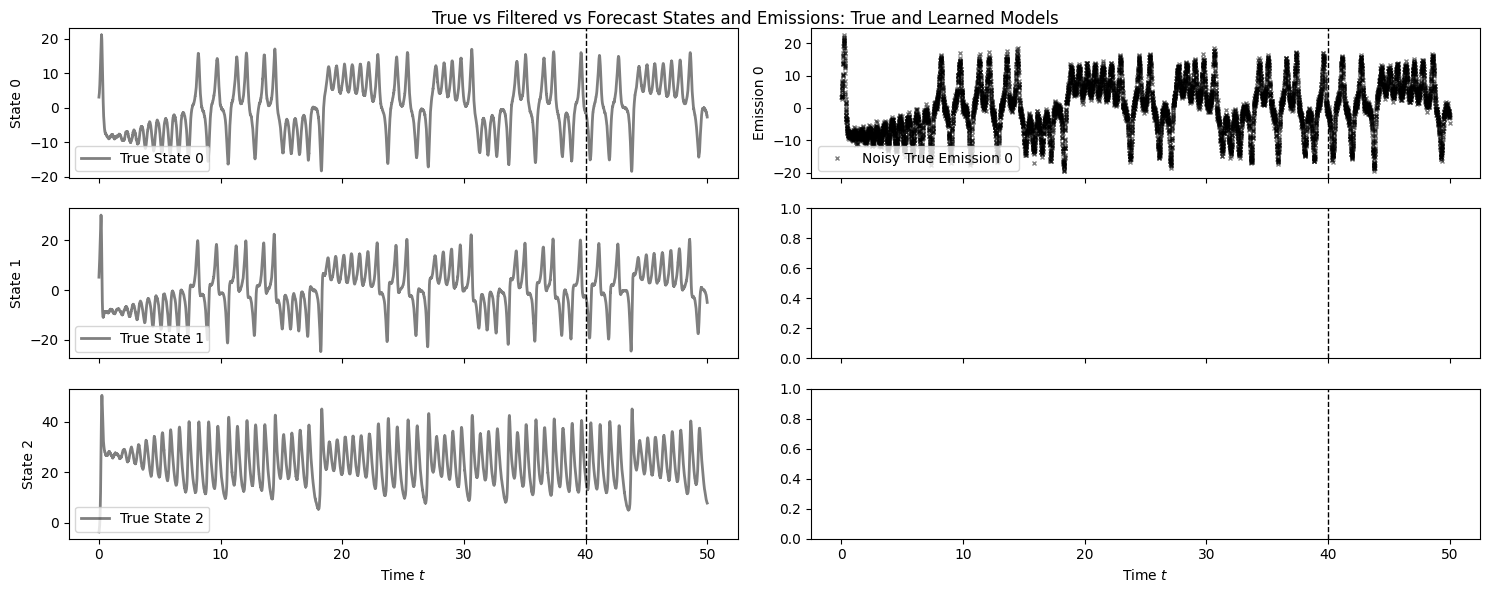

In [6]:
plot_advanced(
    time_grid_all=sim1_t,
    time_grid_filter=sim1_t_filter,
    time_grid_forecast=sim1_t_forecast,
    true_states=sim1_states,
    true_emissions_noisy=sim1_emissions,
    emission_function=sim1_params.emissions.emission_function
)

### State estimation with Extended Kalman Filter

In [7]:
# Filter: EKF
from continuous_discrete_nonlinear_gaussian_ssm import EKFHyperParams

In [8]:
# Execute the EKF filter
sim1_ekf_filtered = cdnlgssm_filter(
    sim1_params,
    sim1_emissions[:sim1_num_timesteps_filter], # Filter based on the first part of the data
    sim1_t_filter,
    hyperparams=EKFHyperParams()
)


In [9]:
# Compute the emissions corresponding to the filtered states, according to the EKF filter
(sim1_ekf_filtered_emissions_means, sim1_ekf_filtered_emissions_covariance) = cdnlgssm_emissions(
    params = sim1_params,
    t_states = sim1_t_filter,
    state_means = sim1_ekf_filtered.filtered_means,
    state_covs = sim1_ekf_filtered.filtered_covariances,
    inputs = None,
    hyperparams = EKFHyperParams(),
    key = next(keys),
)

In [10]:
# Compute the emissions corresponding to the filtered states, according to the model's emission function's mean
(sim1_ekf_filtered_emissions_expected, _) = cdnlgssm_emissions(
    params = sim1_params,
    t_states = sim1_t_filter,
    state_means = sim1_ekf_filtered.filtered_means,
    state_covs = None,
    inputs = None,
    hyperparams = None,
    key = next(keys),
)

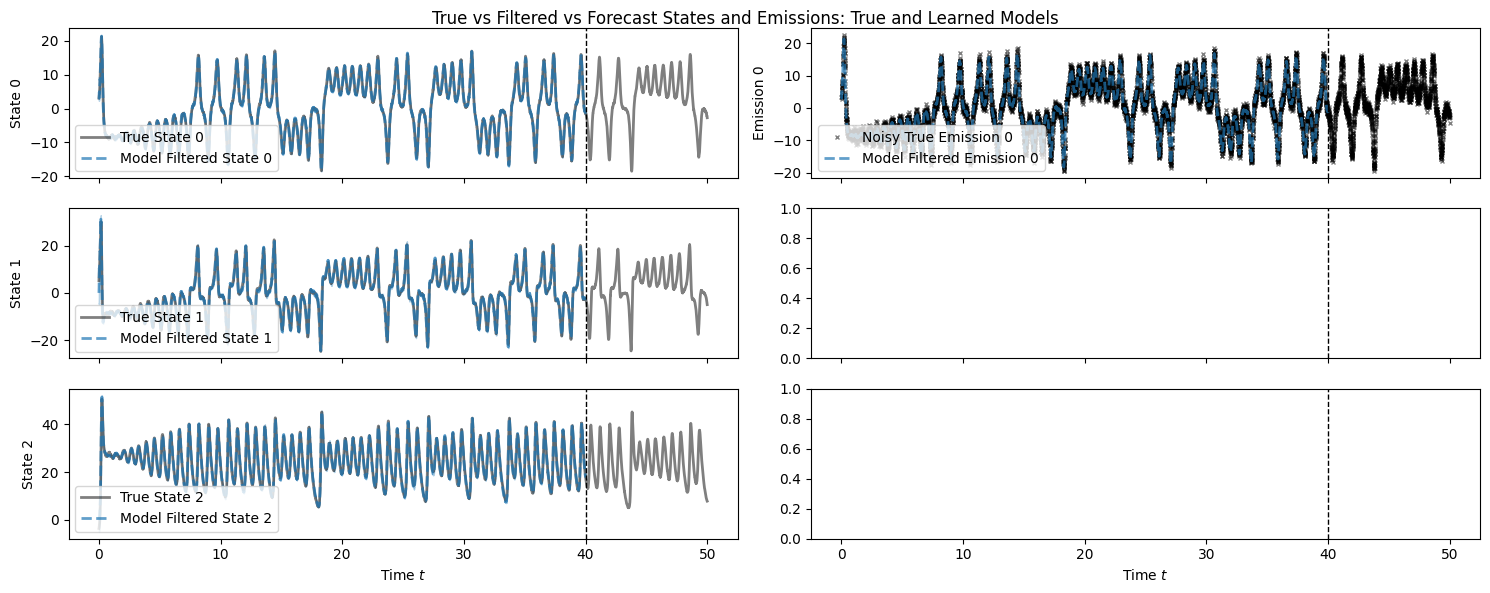

In [11]:
# Plot the true states and emissions, and the EKF estimates
plot_advanced(
        time_grid_all=sim1_t,
        time_grid_filter=sim1_t_filter,
        time_grid_forecast=sim1_t_forecast,
        true_states=sim1_states,
        true_emissions_noisy=sim1_emissions,
        emission_function=sim1_params.emissions.emission_function,
        model_filtered_states=sim1_ekf_filtered.filtered_means,
        model_filtered_covariances=sim1_ekf_filtered.filtered_covariances,
        t_start=None,
        t_end=None,
    )

In [12]:
### Compute and print RMSE between true states and EKF estimates
compute_and_print_rmse_comparison(
    sim1_states[:sim1_num_timesteps_filter, -1],
    sim1_ekf_filtered.filtered_means[:,-1],
    1,
    "EKF"
)

The RMSE of the EKF estimate is         : 0.50
The std of measurement noise is         : 1.00


In [13]:
# EKF forecasting: Distributional forecast
# Initialize at last filtered state's posterior Gaussian distribution 
from tensorflow_probability.substrates.jax.distributions import MultivariateNormalFullCovariance as MVN
ekf_init_forecast = MVN(
    sim1_ekf_filtered.filtered_means[-1,:],
    sim1_ekf_filtered.filtered_covariances[-1,:]
)
ekf_init_time = sim1_t_filter[-1]
# With this mean and covariance
print(ekf_init_time)
print(ekf_init_forecast.mean())
print(ekf_init_forecast.covariance())


[40.00]
[-1.57 -2.77 17.73]
[[0.07 0.08 -0.01]
 [0.08 0.20 -0.02]
 [-0.01 -0.02 0.18]]


In [14]:
# Execute the EKF forecast, using the last filtered state as initial forecast
sim1_ekf_forecast = cdnlgssm_forecast(
    params = sim1_params,
    init_forecast = ekf_init_forecast,
    t_init = ekf_init_time,
    t_forecast=sim1_t_forecast,
    hyperparams=EKFHyperParams()
)

In [15]:
# Compute the emissions corresponding to the forecasted states, according to the EKF filter
(sim1_ekf_forecast_emissions_means, sim1_ekf_forecast_emissions_covariance) = cdnlgssm_emissions(
    params = sim1_params,
    t_states = sim1_t_forecast,
    state_means = sim1_ekf_forecast.forecasted_state_means,
    state_covs = sim1_ekf_forecast.forecasted_state_covariances,
    inputs = None,
    hyperparams = EKFHyperParams(),
    key = next(keys),
)

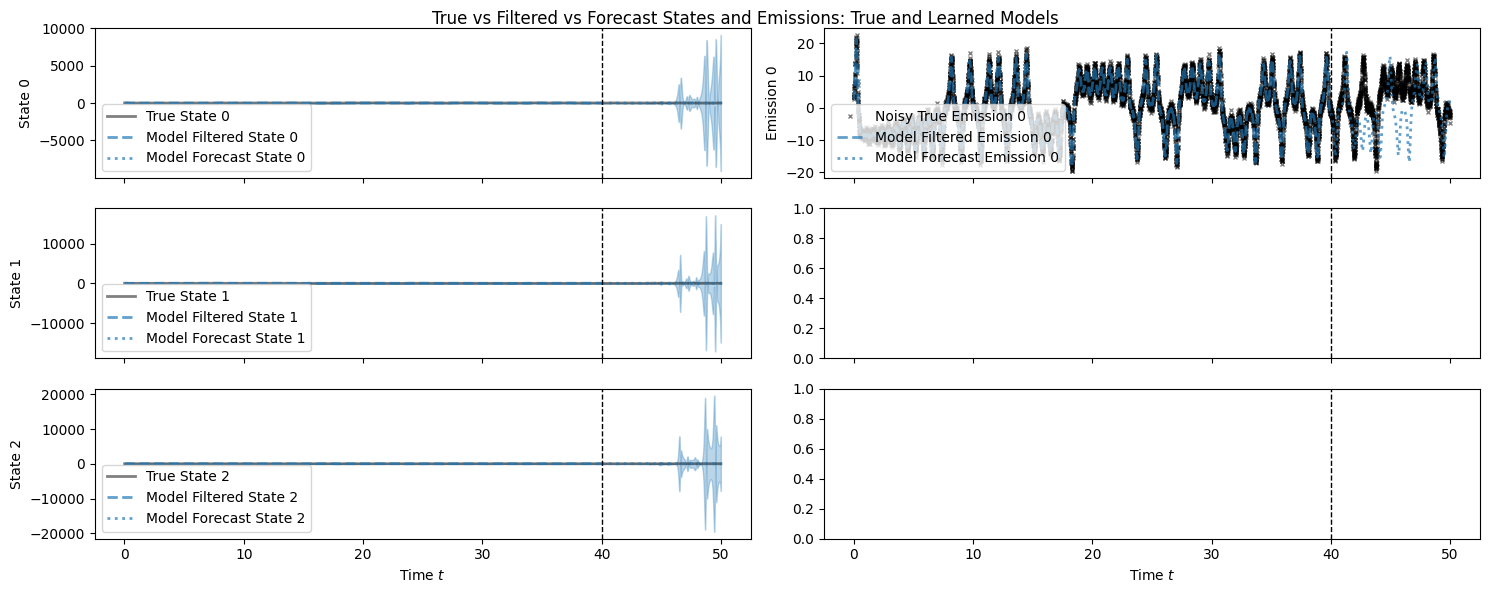

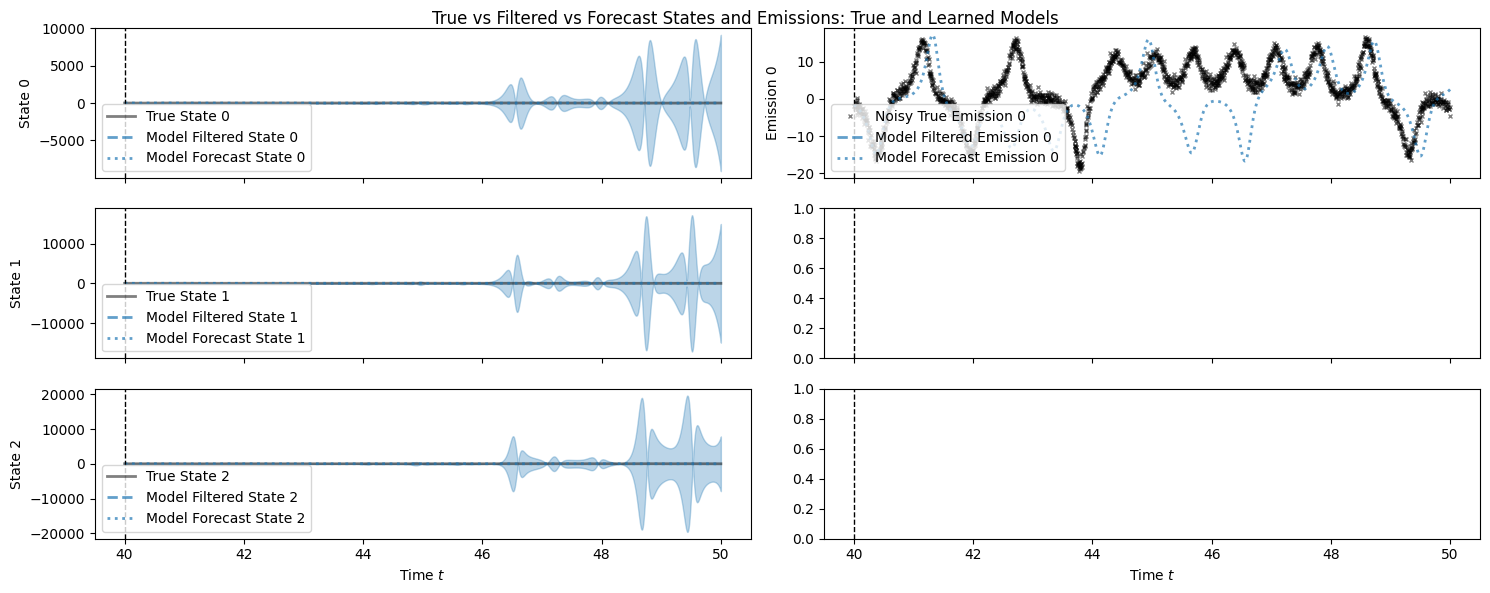

In [16]:
# Plot the true states and emissions, and the EKF estimates
for (t_start, t_end) in [(None, None), (T_filter, T_total)]:
    plot_advanced(
            time_grid_all=sim1_t,
            time_grid_filter=sim1_t_filter,
            time_grid_forecast=sim1_t_forecast,
            true_states=sim1_states,
            true_emissions_noisy=sim1_emissions,
            emission_function=sim1_params.emissions.emission_function,
            model_filtered_states=sim1_ekf_filtered.filtered_means,
            model_filtered_covariances=sim1_ekf_filtered.filtered_covariances,
            model_forecast_states=sim1_ekf_forecast.forecasted_state_means,
            model_forecast_covariances=sim1_ekf_forecast.forecasted_state_covariances,
            t_start=t_start,
            t_end=t_end,
        )

In [17]:
# EKF forecasting: Path-based forecast
# Initialize at last filtered state mean
ekf_init_path_forecast = sim1_ekf_filtered.filtered_means[-1,:]

In [18]:
# Execute the forecast, using EKF's last filtered mean state as initial forecast
sim1_forecast_ekf_path = cdnlgssm_forecast(
    params = sim1_params,
    init_forecast = ekf_init_path_forecast,
    t_init = ekf_init_time,
    t_forecast=sim1_t_forecast,
    hyperparams=EKFHyperParams(),
    key = next(keys)
)

In [19]:
# Compute the emissions corresponding to the forecasted state path, according to the model's emission function's mean
(sim1_ekf_filtered_emissions_expected, _) = cdnlgssm_emissions(
    params = sim1_params,
    t_states = sim1_t_forecast,
    state_means = sim1_forecast_ekf_path.forecasted_state_path,
    state_covs = None,
    inputs = None,
    hyperparams = None,
    key = next(keys),
)

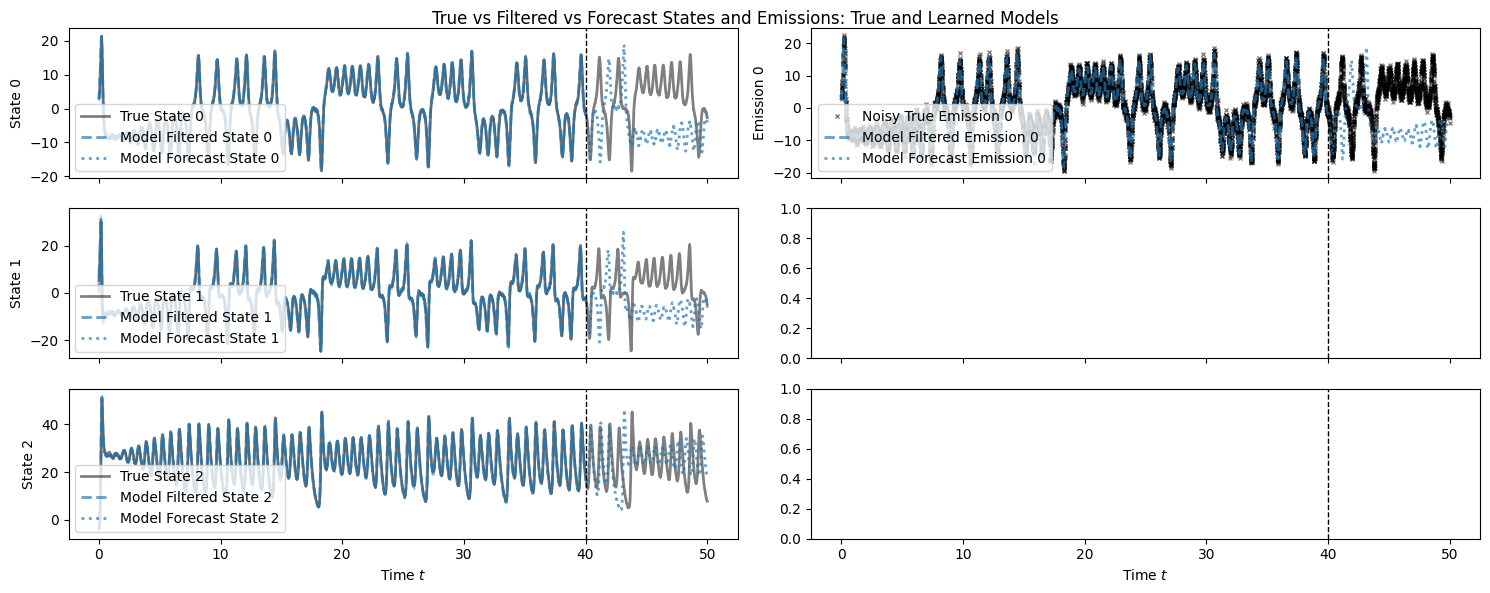

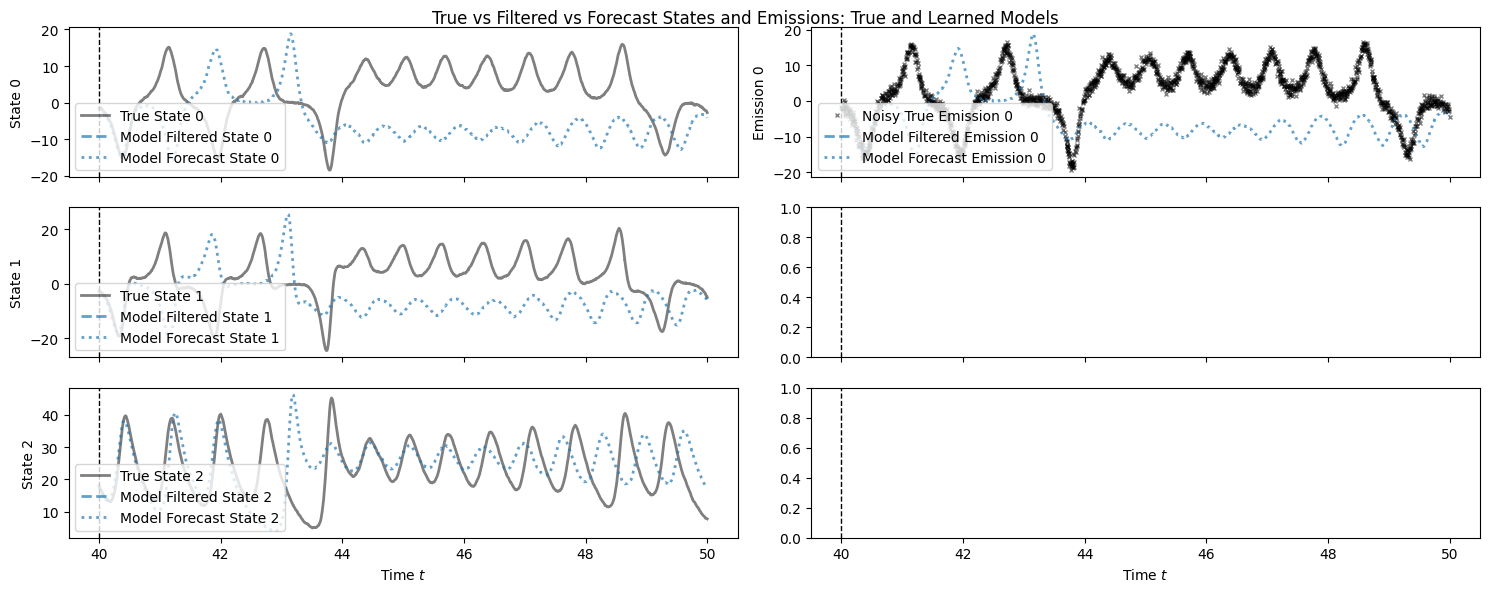

In [20]:
# Plot the true states and emissions, and the EKF estimates
for (t_start, t_end) in [(None, None), (T_filter, T_total)]:
    plot_advanced(
            time_grid_all=sim1_t,
            time_grid_filter=sim1_t_filter,
            time_grid_forecast=sim1_t_forecast,
            true_states=sim1_states,
            true_emissions_noisy=sim1_emissions,
            emission_function=sim1_params.emissions.emission_function,
            model_filtered_states=sim1_ekf_filtered.filtered_means,
            model_filtered_covariances=sim1_ekf_filtered.filtered_covariances,
            model_forecast_states=sim1_forecast_ekf_path.forecasted_state_path,
            t_start=t_start,
            t_end=t_end,
        )

### State estimation with Extended Kalman Smoother

In [21]:
# Execute the EKS: first_order
cd_eks_posterior = cdnlgssm_smoother(
    sim1_params,
    sim1_emissions[:sim1_num_timesteps_filter], # Filter based on the first part of the data
    sim1_t_filter,
    hyperparams=EKFHyperParams(),
)

In [22]:
# Compute the emissions corresponding to the filtered states, according to the EKS filter
(sim1_eks_filtered_emissions_means, sim1_eks_filtered_emissions_covariance) = cdnlgssm_emissions(
    params = sim1_params,
    t_states = sim1_t_filter,
    state_means = cd_eks_posterior.filtered_means,
    state_covs = cd_eks_posterior.filtered_covariances,
    inputs = None,
    hyperparams = EKFHyperParams(),
    key = next(keys),
)

In [23]:
# Compute the emissions corresponding to the smoothed states, according to the EKS SMOOTHER
(sim1_eks_smoothed_emissions_means, sim1_eks_smoothed_emissions_covariance) = cdnlgssm_emissions(
    params = sim1_params,
    t_states = sim1_t_filter,
    state_means = cd_eks_posterior.smoothed_means,
    state_covs = cd_eks_posterior.smoothed_covariances,
    inputs = None,
    hyperparams = EKFHyperParams(),
    key = next(keys),
)

In [24]:
# Compute the emissions corresponding to the filtered states, according to the model's emission function's mean
(sim1_eks_filtered_emissions_expected, _) = cdnlgssm_emissions(
    params = sim1_params,
    t_states = sim1_t_filter,
    state_means = cd_eks_posterior.filtered_means,
    state_covs = None,
    inputs = None,
    hyperparams = None,
    key = next(keys),
)

In [25]:
# Compute the emissions corresponding to the smoothed states, according to the model's emission function's mean
(sim1_eks_smoothed_emissions_expected, _) = cdnlgssm_emissions(
    params = sim1_params,
    t_states = sim1_t_filter,
    state_means = cd_eks_posterior.smoothed_means,
    state_covs = None,
    inputs = None,
    hyperparams = None,
    key = next(keys),
)

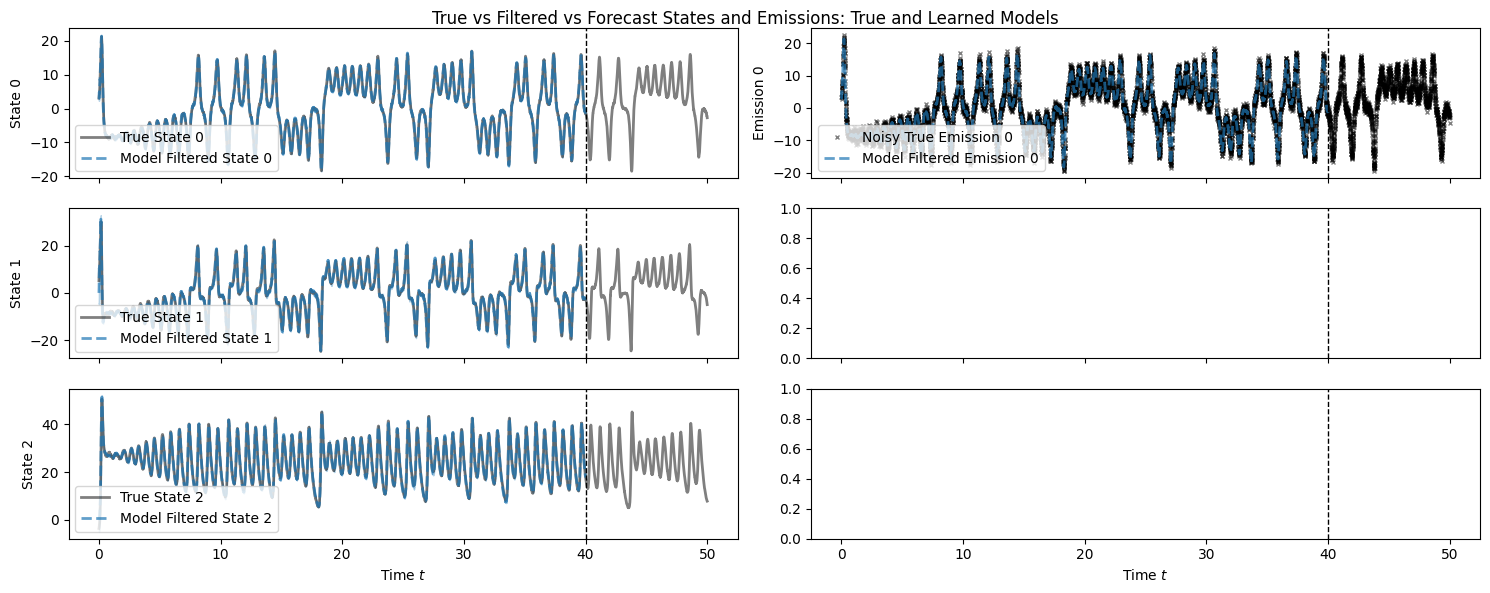

In [26]:
# Plot the true states and emissions, and the EKS estimates
plot_advanced(
        time_grid_all=sim1_t,
        time_grid_filter=sim1_t_filter,
        time_grid_forecast=sim1_t_forecast,
        true_states=sim1_states,
        true_emissions_noisy=sim1_emissions,
        emission_function=sim1_params.emissions.emission_function,
        model_filtered_states=cd_eks_posterior.filtered_means,
        model_filtered_covariances=cd_eks_posterior.filtered_covariances,
        t_start=None,
        t_end=None,
    )

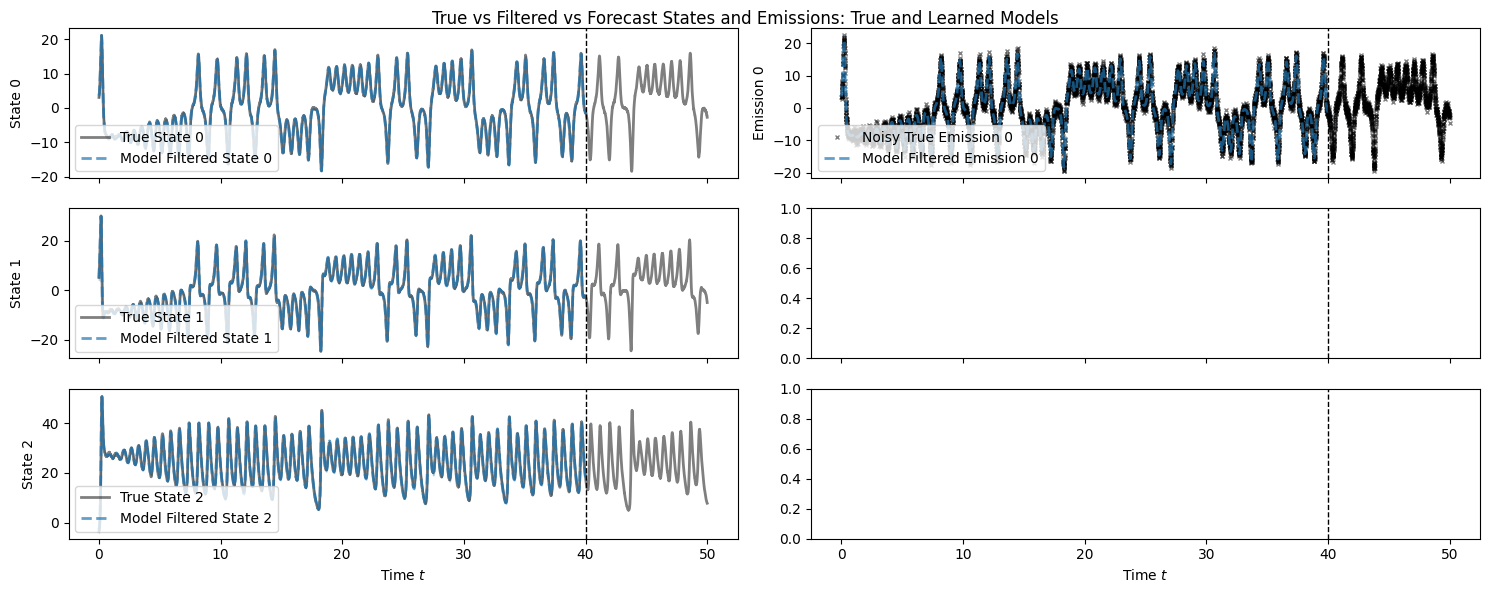

In [27]:
# Plot the true states and emissions, and the EKS estimates
plot_advanced(
        time_grid_all=sim1_t,
        time_grid_filter=sim1_t_filter,
        time_grid_forecast=sim1_t_forecast,
        true_states=sim1_states,
        true_emissions_noisy=sim1_emissions,
        emission_function=sim1_params.emissions.emission_function,
        model_filtered_states=cd_eks_posterior.smoothed_means,
        model_filtered_covariances=cd_eks_posterior.smoothed_covariances,
        t_start=None,
        t_end=None,
    )

In [28]:
compute_and_print_rmse_comparison(
    sim1_states[:sim1_num_timesteps_filter, -1],
    cd_eks_posterior.filtered_means[:,-1],
    1,
    "EKS filtering"
)

The RMSE of the EKS filtering estimate is: 0.50
The std of measurement noise is         : 1.00


In [29]:
compute_and_print_rmse_comparison(
    sim1_states[:sim1_num_timesteps_filter, -1],
    cd_eks_posterior.smoothed_means[:,-1],
    1,
    "EKS smoother"
)

The RMSE of the EKS smoother estimate is: 0.45
The std of measurement noise is         : 1.00


In [30]:
print(state_dim)

3


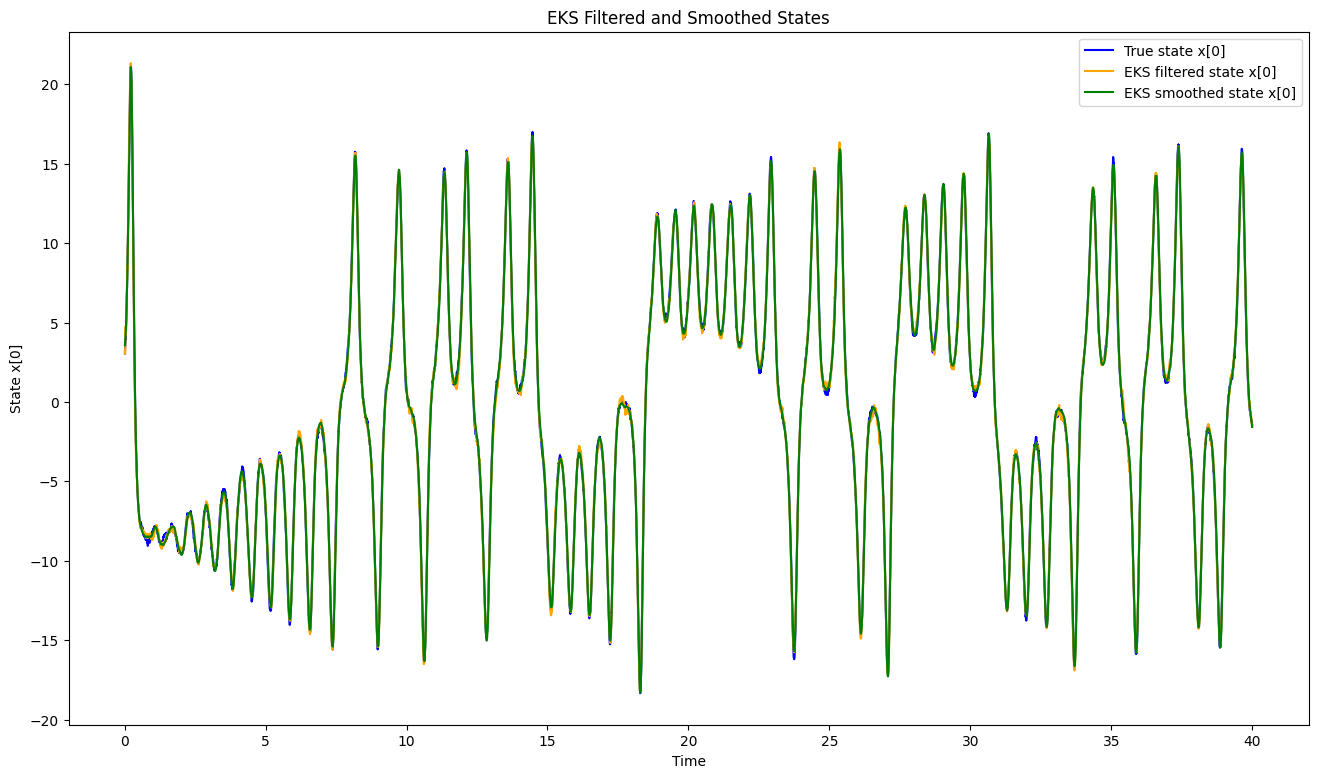

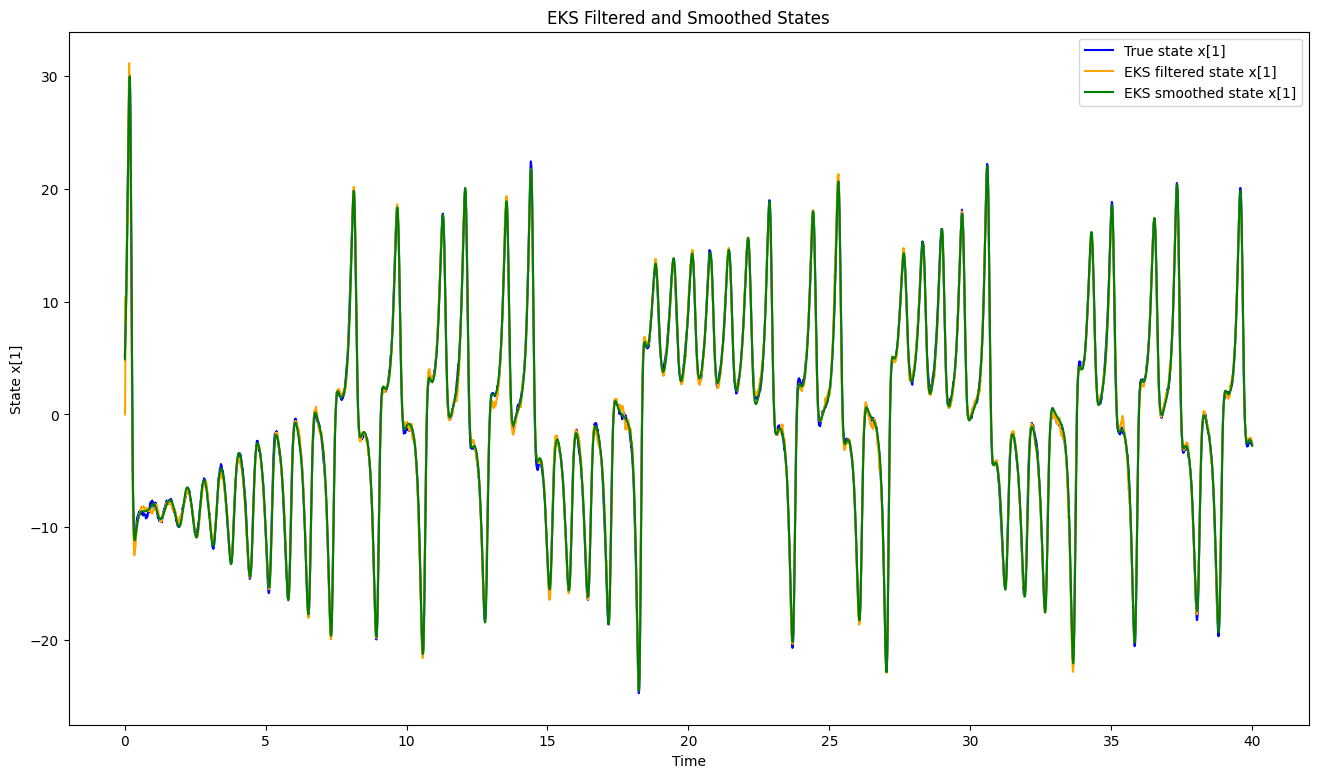

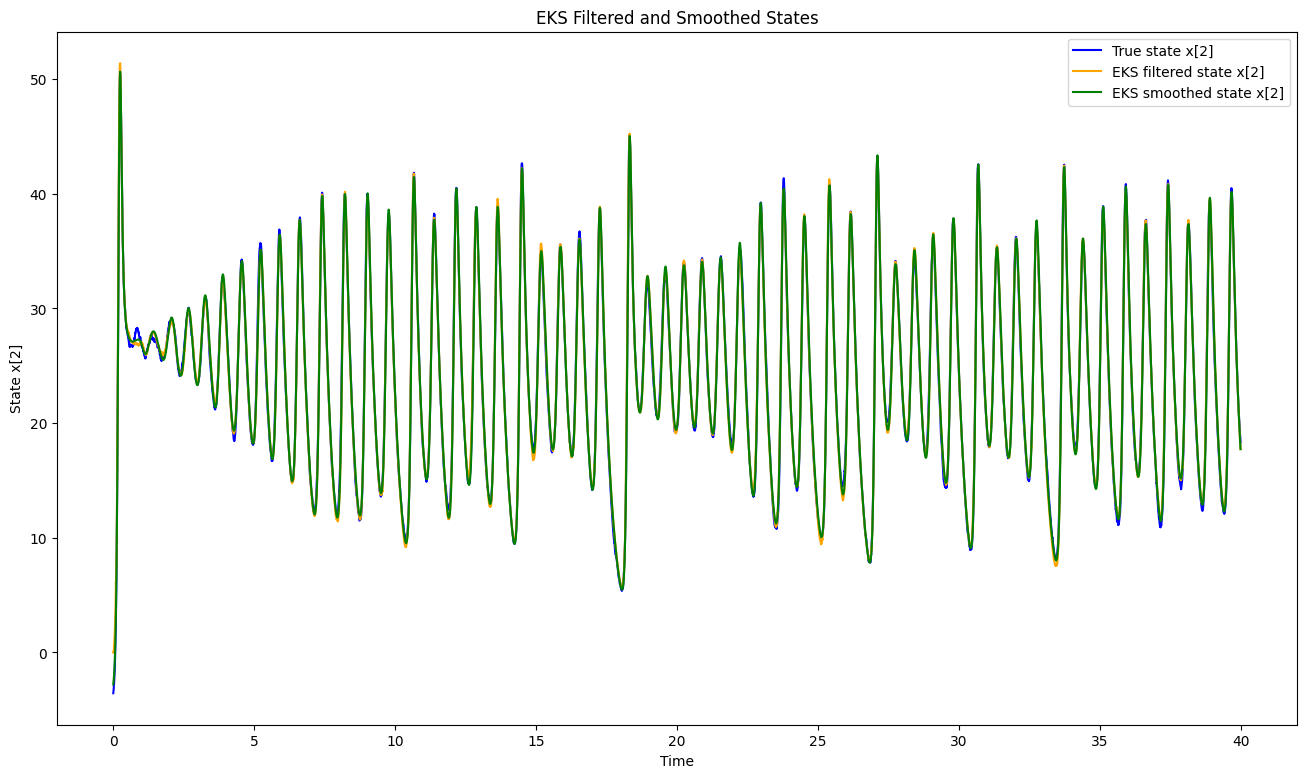

In [31]:
# Plot the true, EKS filtered and smoothed states

# For each state in state_dim
for n_state in range(state_dim):
    plt.figure(figsize=(16, 9))
    # Plot the true states
    plt.plot(sim1_t_filter, sim1_states[:sim1_num_timesteps_filter, n_state], label="True state x[{}]".format(n_state), color='blue')
    # Plot the EKS filtered states
    plt.plot(sim1_t_filter, cd_eks_posterior.filtered_means[:, n_state], label="EKS filtered state x[{}]".format(n_state), color='orange')
    # Plot the EKS smoothed states
    plt.plot(sim1_t_filter, cd_eks_posterior.smoothed_means[:, n_state], label="EKS smoothed state x[{}]".format(n_state), color='green')
    # Add labels and legend
    plt.xlabel("Time")
    plt.ylabel("State x[{}]".format(n_state))
    plt.title("EKS Filtered and Smoothed States")
    plt.legend()
    plt.show()

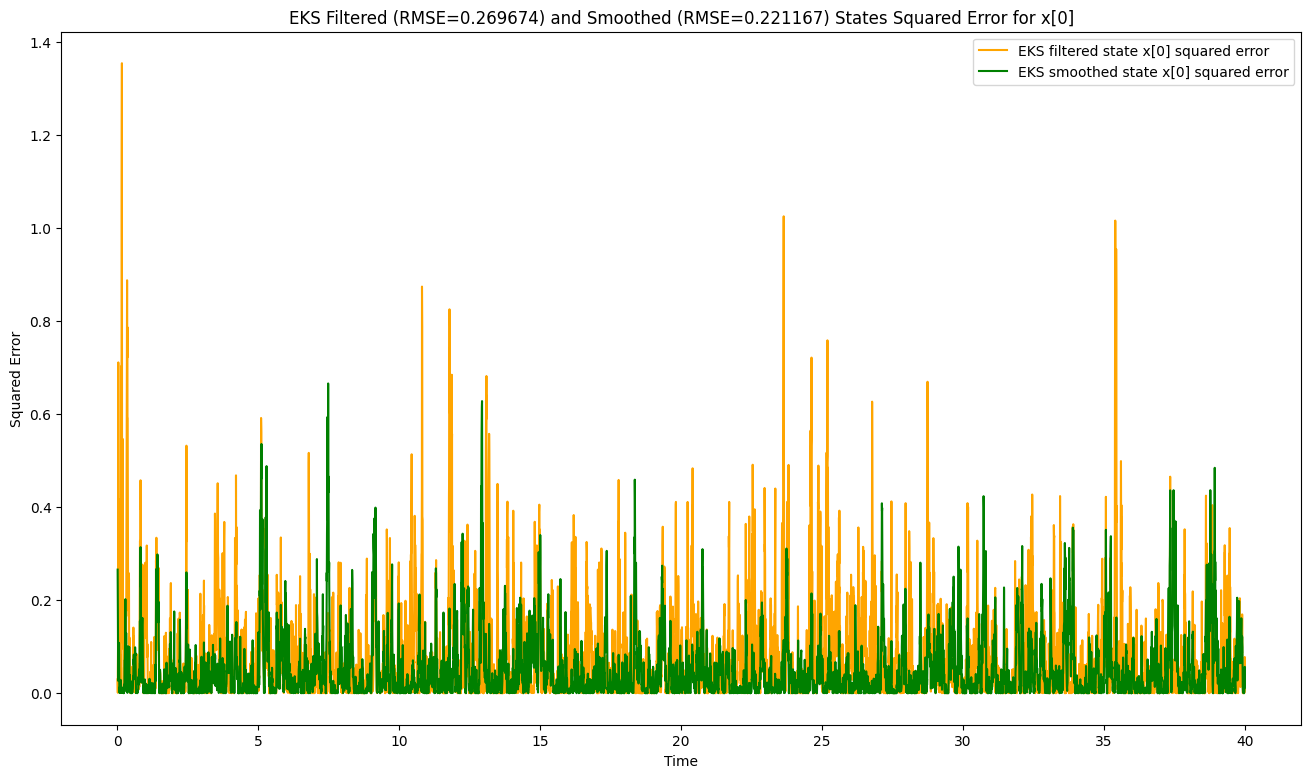

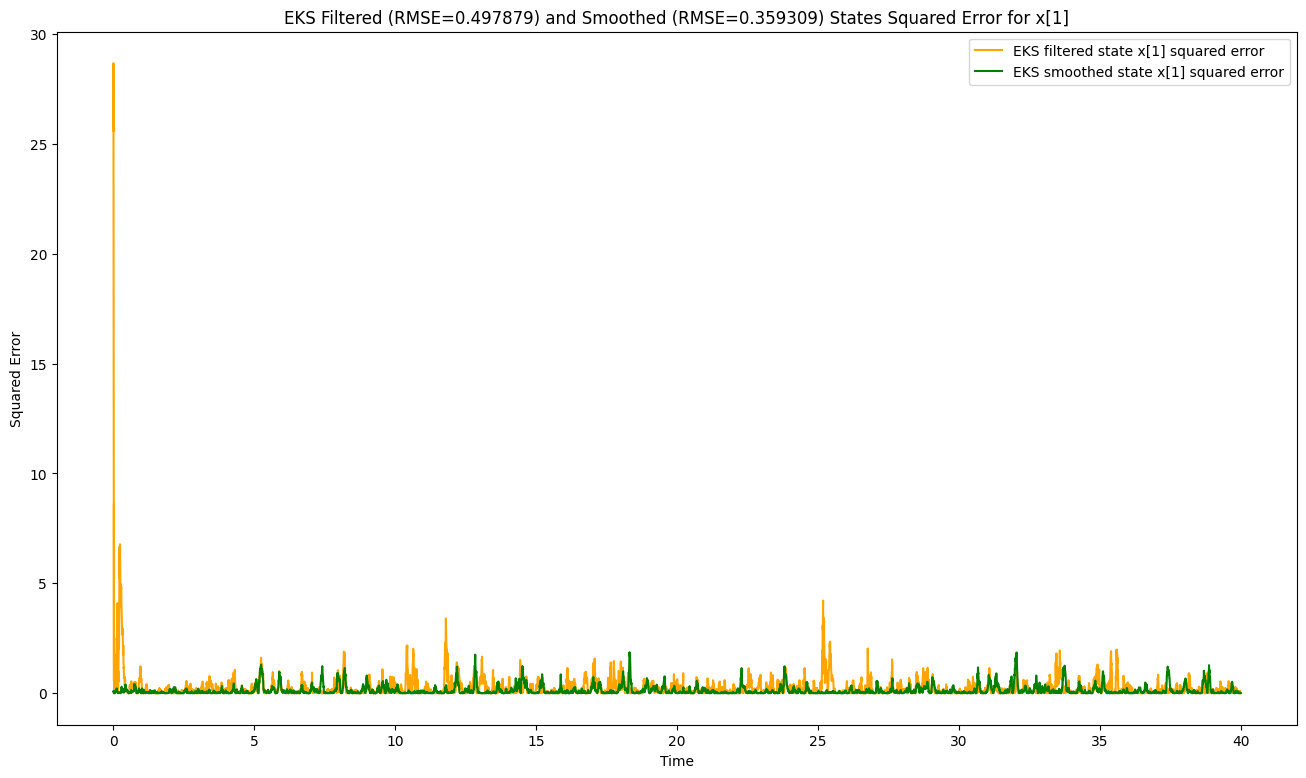

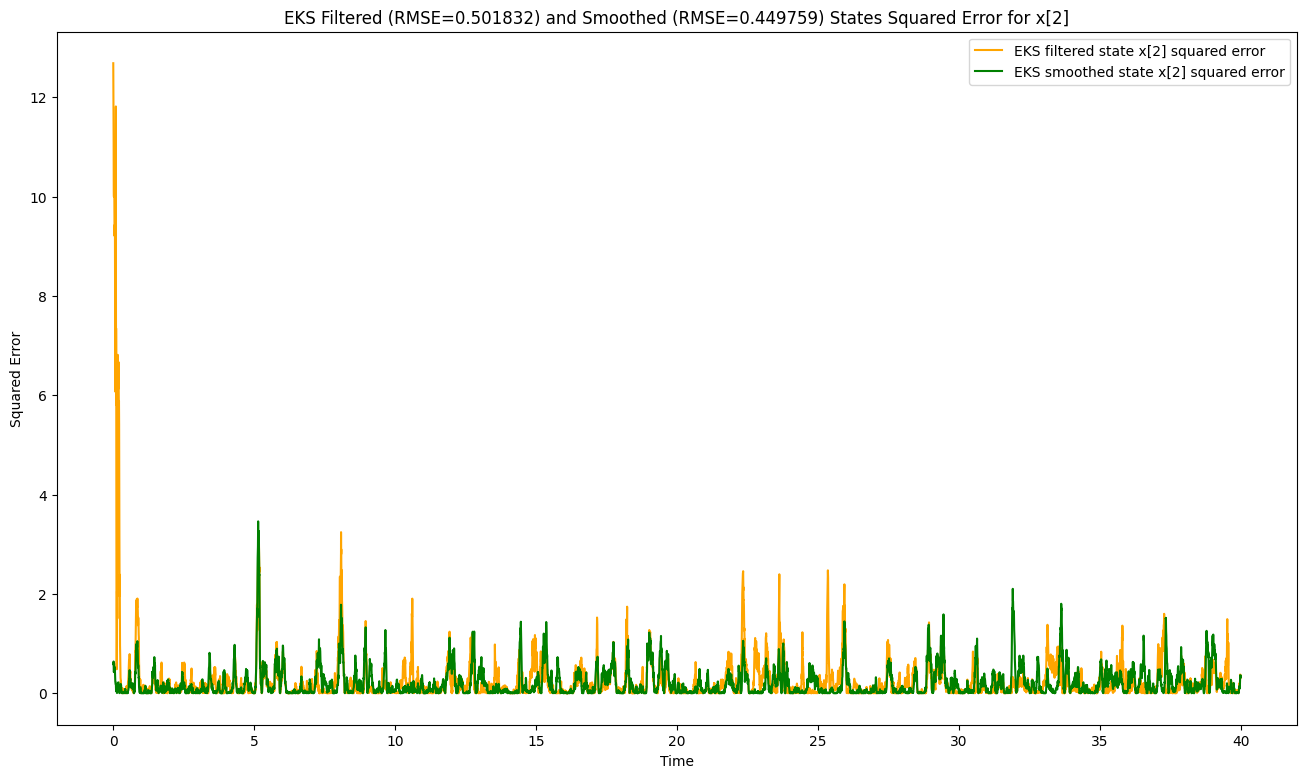

In [32]:
# Plot the squared error of the EKS filtered and smoothed states, over time, per dimension

for n_state in range(state_dim):
    plt.figure(figsize=(16, 9))
    # Plot the squared error of the EKS filtered states
    plt.plot(sim1_t_filter, (sim1_states[:sim1_num_timesteps_filter, n_state] - cd_eks_posterior.filtered_means[:, n_state]) ** 2,
             label="EKS filtered state x[{}] squared error".format(n_state), color='orange')
    # Plot the squared error of the EKS smoothed states
    plt.plot(sim1_t_filter, (sim1_states[:sim1_num_timesteps_filter, n_state] - cd_eks_posterior.smoothed_means[:, n_state]) ** 2,
             label="EKS smoothed state x[{}] squared error".format(n_state), color='green')
    # Add labels and legend
    plt.xlabel("Time")
    plt.ylabel("Squared Error")
    plt.title("EKS Filtered (RMSE={:2f}) and Smoothed (RMSE={:2f}) States Squared Error for x[{}]".format(
        jnp.sqrt(jnp.mean((sim1_states[:sim1_num_timesteps_filter, n_state] - cd_eks_posterior.filtered_means[:, n_state]) ** 2)),
        jnp.sqrt(jnp.mean((sim1_states[:sim1_num_timesteps_filter, n_state] - cd_eks_posterior.smoothed_means[:, n_state]) ** 2)),
        n_state,
        )
    )
    plt.legend()
    plt.show()

In [33]:
# EKS forecasting: Distributional forecast
# Initialize at last smoothed state's posterior Gaussian distribution 
from tensorflow_probability.substrates.jax.distributions import MultivariateNormalFullCovariance as MVN
eks_init_forecast = MVN(
    cd_eks_posterior.smoothed_means[-1,:],
    cd_eks_posterior.smoothed_covariances[-1,:]
)
eks_init_time = sim1_t_filter[-1]
# With this mean and covariance
print(eks_init_time)
print(eks_init_forecast.mean())
print(eks_init_forecast.covariance())


[40.00]
[-1.57 -2.77 17.73]
[[0.07 0.08 -0.01]
 [0.08 0.20 -0.02]
 [-0.01 -0.02 0.18]]


In [34]:
# Execute the EnKF forecast, using the last smoothed state as initial forecast
sim1_eks_forecast = cdnlgssm_forecast(
    params = sim1_params,
    init_forecast = eks_init_forecast,
    t_init = eks_init_time,
    t_forecast=sim1_t_forecast,
    hyperparams=EKFHyperParams()
)

In [35]:
# Compute the emissions corresponding to the forecasted states, according to the EKS
(sim1_eks_forecast_emissions_means, sim1_eks_forecast_emissions_covariance) = cdnlgssm_emissions(
    params = sim1_params,
    t_states = sim1_t_forecast,
    state_means = sim1_eks_forecast.forecasted_state_means,
    state_covs = sim1_eks_forecast.forecasted_state_covariances,
    inputs = None,
    hyperparams = EKFHyperParams(),
    key = next(keys),
)

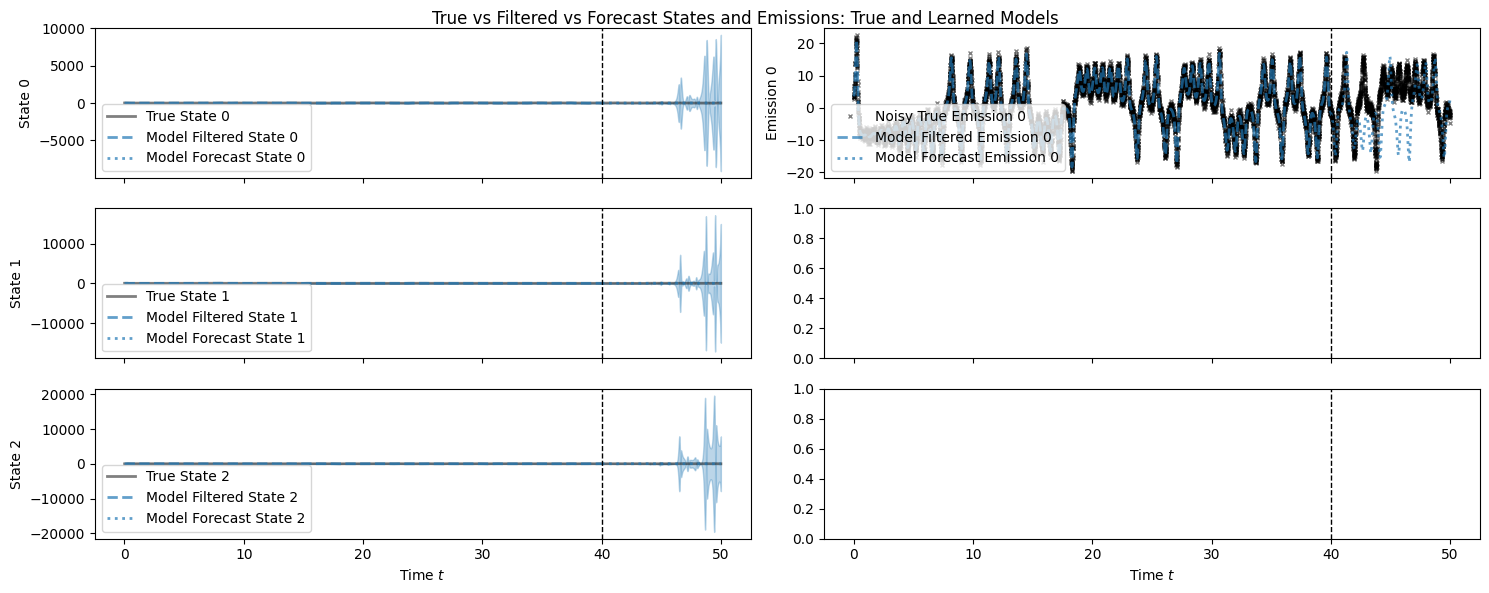

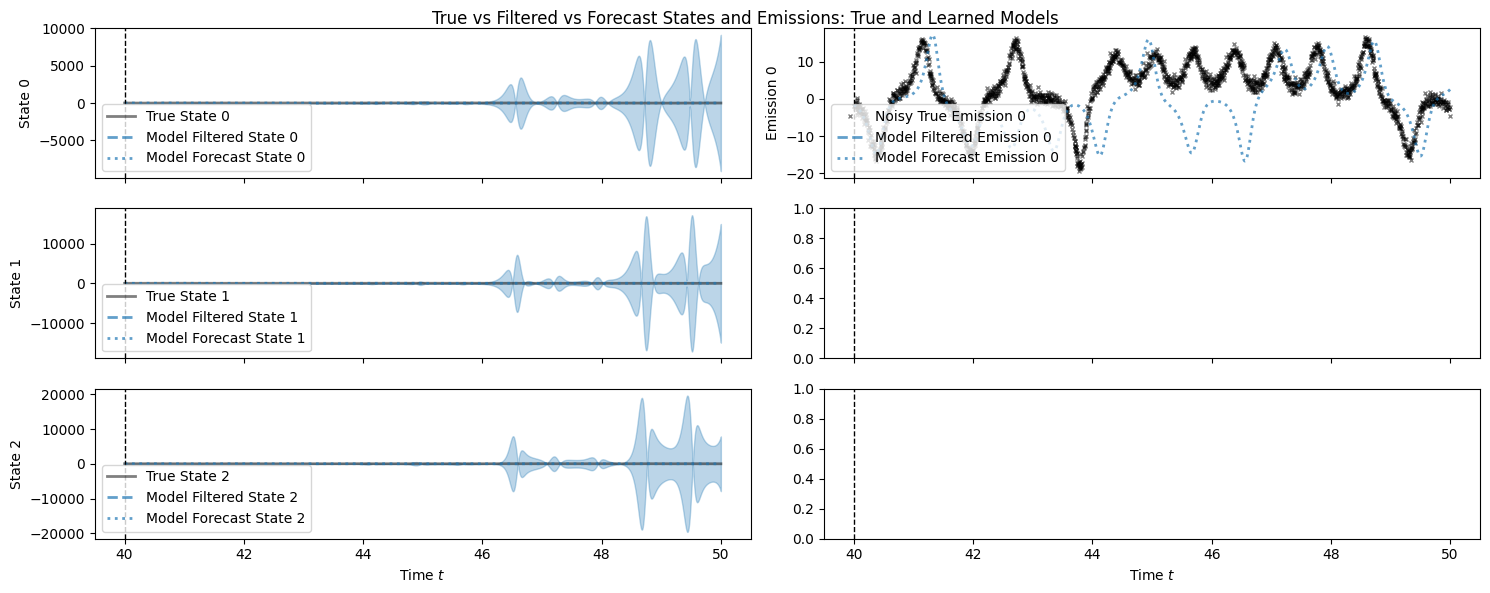

In [36]:
# Plot the true states and emissions, and the EKS estimates
for (t_start, t_end) in [(None, None), (T_filter, T_total)]:
    plot_advanced(
            time_grid_all=sim1_t,
            time_grid_filter=sim1_t_filter,
            time_grid_forecast=sim1_t_forecast,
            true_states=sim1_states,
            true_emissions_noisy=sim1_emissions,
            emission_function=sim1_params.emissions.emission_function,
            model_filtered_states=cd_eks_posterior.smoothed_means,
            model_filtered_covariances=cd_eks_posterior.smoothed_covariances,
            model_forecast_states=sim1_eks_forecast.forecasted_state_means,
            model_forecast_covariances=sim1_eks_forecast.forecasted_state_covariances,
            t_start=t_start,
            t_end=t_end,
        )

In [37]:
# EKS forecasting: Path-based forecast
# Initialize at last smoothed state mean
eks_init_path_forecast = cd_eks_posterior.smoothed_means[-1,:]

In [38]:
# Execute the forecast, using EKS's last smoothed mean state as initial forecast
sim1_forecast_eks_path = cdnlgssm_forecast(
    params = sim1_params,
    init_forecast = eks_init_path_forecast,
    t_init = eks_init_time,
    t_forecast=sim1_t_forecast,
    hyperparams=EKFHyperParams(),
    key = next(keys)
)

In [39]:
# Compute the emissions corresponding to the forecasted state path, according to the model's emission function's mean
(sim1_eks_emissions_expected, _) = cdnlgssm_emissions(
    params = sim1_params,
    t_states = sim1_t_forecast,
    state_means = sim1_forecast_eks_path.forecasted_state_path,
    state_covs = None,
    inputs = None,
    hyperparams = None,
    key = next(keys),
)

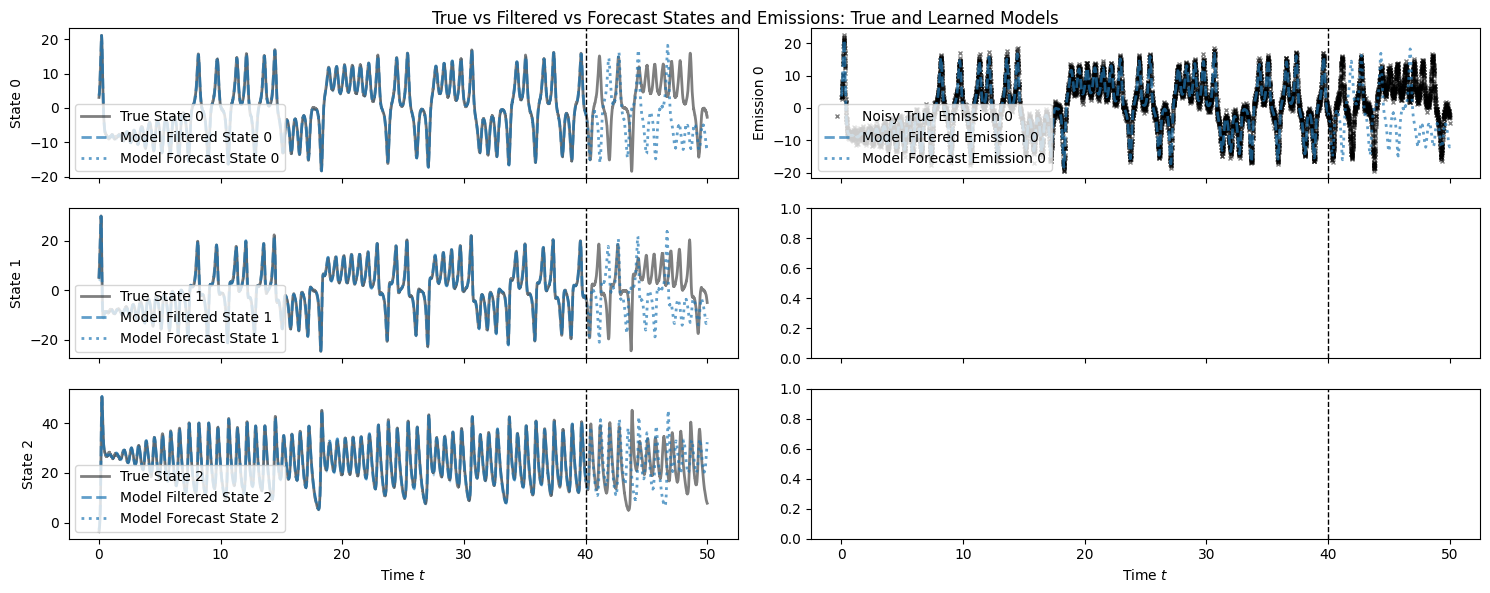

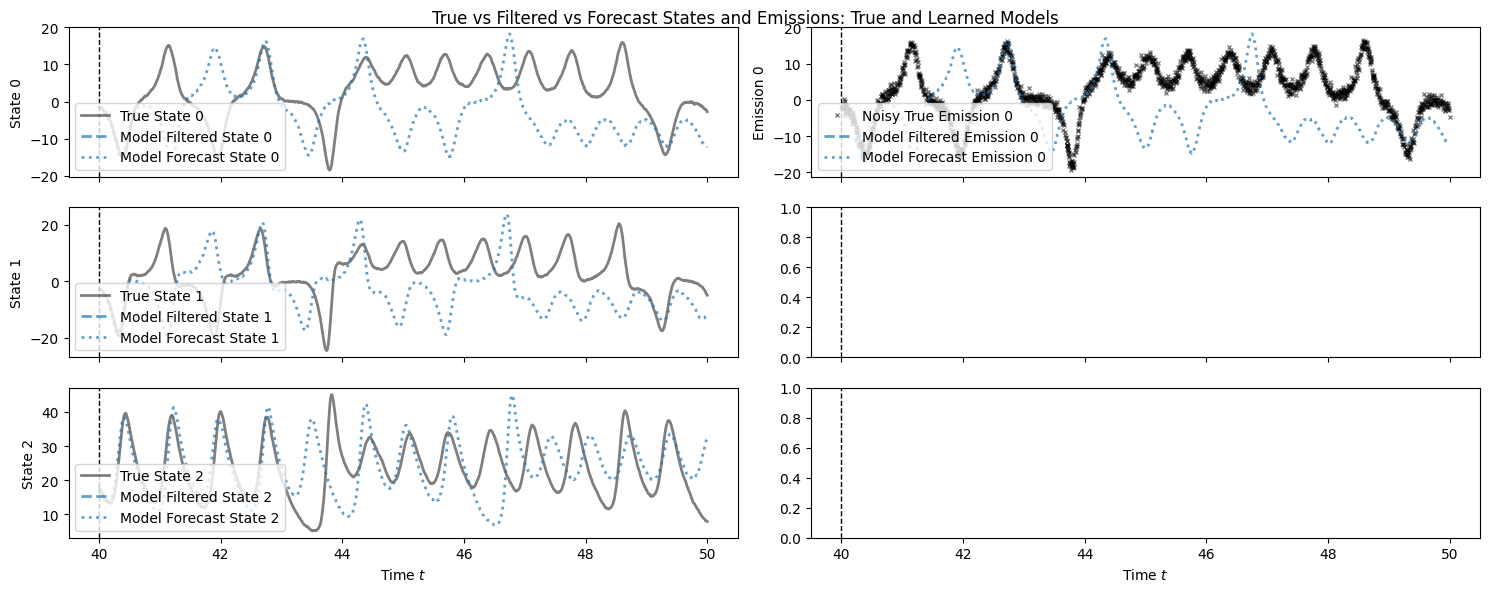

In [40]:
# Plot the true states and emissions, and the EKS estimates
for (t_start, t_end) in [(None, None), (T_filter, T_total)]:
    plot_advanced(
            time_grid_all=sim1_t,
            time_grid_filter=sim1_t_filter,
            time_grid_forecast=sim1_t_forecast,
            true_states=sim1_states,
            true_emissions_noisy=sim1_emissions,
            emission_function=sim1_params.emissions.emission_function,
            model_filtered_states=cd_eks_posterior.smoothed_means,
            model_filtered_covariances=cd_eks_posterior.smoothed_covariances,
            model_forecast_states=sim1_forecast_eks_path.forecasted_state_path,
            t_start=t_start,
            t_end=t_end,
        )